Creación do dataset

División en conxuntos entrenamento e test.

Definir a rede de neuronas

Conven facer unha proba de execución para ver se todo está correcto

Crear a función de entrenamento para un epoch

Entrenar e avaliar

Resumen do entrenamento con algunha gráfica

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt



In [29]:
iris_df = pd.read_csv("../../docs/iris/iris.data", 
                        names=["sepallength","sepalwidth",
                                "petallength","petalwidth","class"])

In [30]:
iris_df.head()

,sepallength,sepalwidth,petallength,petalwidth,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [31]:
iris_df.describe()

,sepallength,sepalwidth,petallength,petalwidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


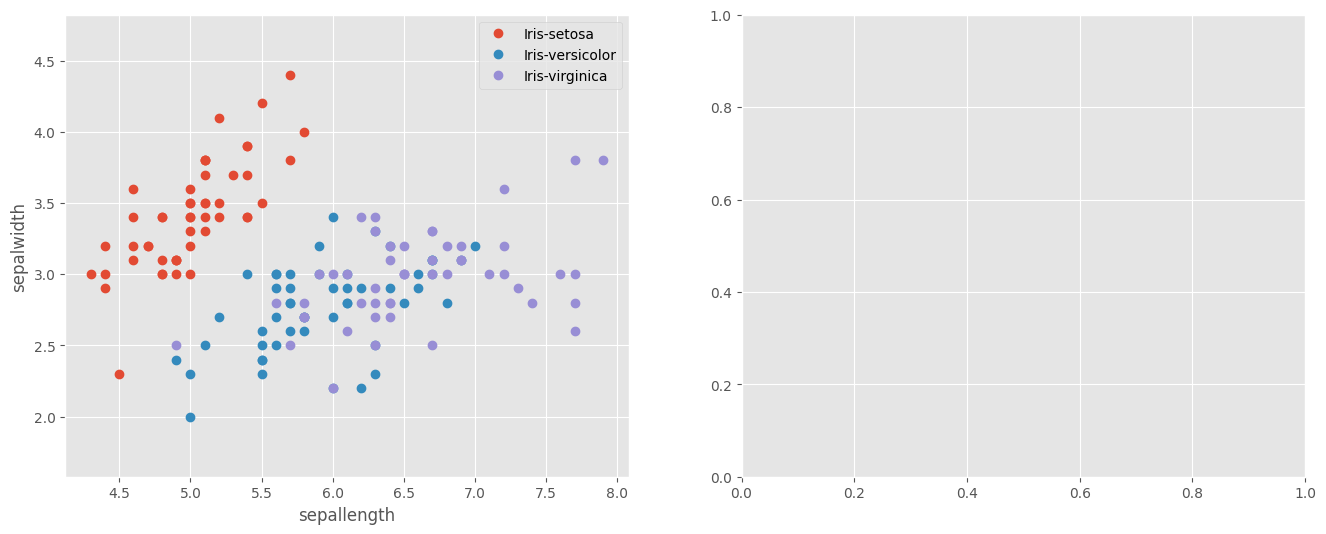

In [32]:
plt.style.use('ggplot')
nomeClases = iris_df["class"].unique()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for target, target_name in enumerate(nomeClases):
    X_plot = iris_df[iris_df["class"] == target_name]
    ax1.plot(X_plot["sepallength"], X_plot["sepalwidth"], 
            linestyle='none', 
            marker='o', 
            label=target_name)
ax1.set_xlabel("sepallength")
ax1.set_ylabel("sepalwidth")
ax1.axis('equal')
ax1.legend()

Para trabajar bien con los datos de entrada hay que hacer una transformación de datos de entrada, no podemos trabajar con entradas categóricas, valores con entrada mejor media 0 y desviación tipica 1 
podemos crear una clase para que hga las transformaciones 

In [33]:
class StandardScaler:

    def __init__(self, mean=None, std=None, epsilon=1e-7):
        """Standard Scaler.
        The class can be used to normalize PyTorch Tensors using native functions. The module does not expect the
        tensors to be of any specific shape; as long as the features are the last dimension in the tensor, the module
        will work fine.
        :param mean: The mean of the features. The property will be set after a call to fit.
        :param std: The standard deviation of the features. The property will be set after a call to fit.
        :param epsilon: Used to avoid a Division-By-Zero exception.
        """
        self.mean = mean
        self.std = std
        self.epsilon = epsilon
    def fit(self, values):
        dims = list(range(values.dim() - 1))
        self.mean = torch.mean(values, dim=dims)
        self.std = torch.std(values, dim=dims)
    def transform(self, values):
        return (values - self.mean) / (self.std + self.epsilon)

    def fit_transform(self, values):
        self.fit(values)
        return self.transform(values)

    def __repr__(self):
        return f"mean: {self.mean}, std:{self.std}, epsilon:{self.epsilon}"
